# I0T Evaluation Notebook

This notebook mirrors the evaluation structure used for `ReAlign.ipynb`, but replaces the alignment step with the `I0T` method implemented in `I0T_implementation.py`.

Plan:
1. Set deterministic seeds and shared experiment configuration.
2. Run Flickr30k with ImageNet labels.
3. Run MSCOCO with ImageNet labels.
4. Run MSRVTT v2.
5. Export compact metrics to JSON.

In [1]:
import copy
import os
import random
import sys

import numpy as np
import torch

sys.path.append(os.path.abspath(".."))

from I0T_implementation import apply_i0t, apply_i0t_with_statistics, fit_i0t_statistics
from I0T_notebook_support import (
    DEFAULT_CONFIGS,
    DEFAULT_MODEL_NAME,
    DEFAULT_PATHS,
    DEFAULT_SEED,
    build_embedding_paths,
    build_flickr30k_i0t_experiment,
    build_mscoco_i0t_experiment,
    build_msrvtt_v2_i0t_experiment,
    evaluate_i0t_flickr30k,
    evaluate_i0t_mscoco_imagenet,
    evaluate_i0t_msrvtt_v2,
    export_i0t_results,
    fit_i0t_statistics_from_loader,
    set_global_seed,
)


In [2]:
seed = 123
g = torch.Generator().manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
device = "cuda:1" if torch.cuda.is_available() else "cpu"


CLIP_MODEL = "ViT-L-16-SigLIP2-256"
CLIP_PRETRAINED = "webli"
MODEL_NAME = f"{CLIP_MODEL}___{CLIP_PRETRAINED}"
MODEL_TAG = MODEL_NAME

EMBEDDING_MODEL_NAME = MODEL_TAG
EMBEDDING_PATHS = build_embedding_paths(EMBEDDING_MODEL_NAME)

print(f"seed={seed}")
print(f"device={device}")
print(f"embedding_model={EMBEDDING_MODEL_NAME}")
print(f"deterministic_algorithms={torch.are_deterministic_algorithms_enabled()}")


seed=123
device=cuda:1
embedding_model=ViT-L-16-SigLIP2-256___webli
deterministic_algorithms=False


## Flickr30k with ImageNet labels

[Loaded] 31783 samples from /mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/ViT-L-16-SigLIP2-256___webli
{'embedding_model': 'ViT-L-16-SigLIP2-256___webli', 'precomputed_dir': '/mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/ViT-L-16-SigLIP2-256___webli', 'train_size': 24376, 'test_size': 6095, 'n_clusters': 465}


RMG over batches: 100%|██████████| 3/3 [00:00<00:00, 16.96it/s]


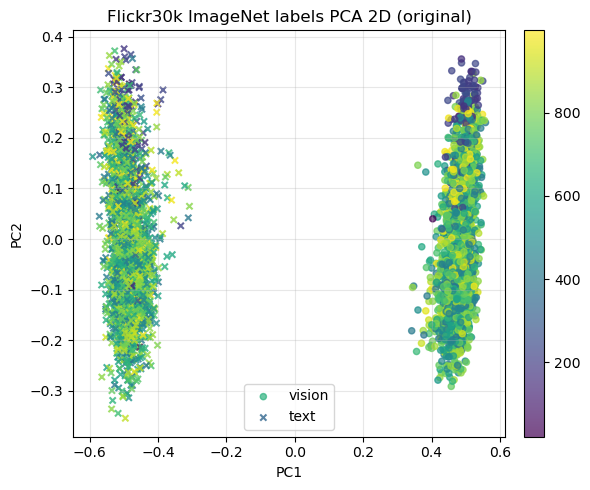

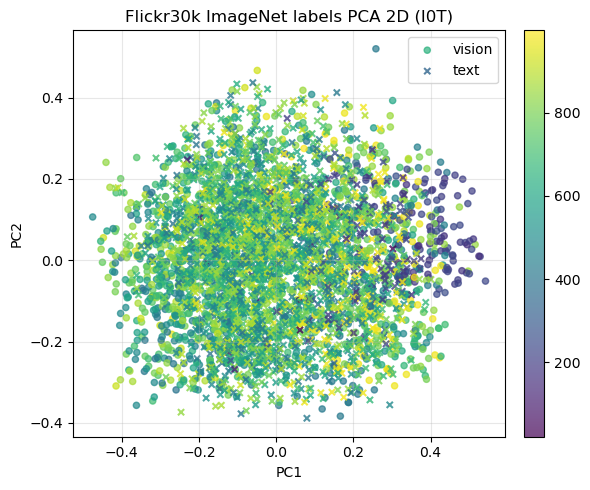

{'method': 'I0T',
 'dataset': 'flickr30k',
 'retrieval_orig': {1: 0.7744052410125732,
  5: 0.9219031929969788,
  10: 0.9543888568878174},
 'retrieval_i0t': {1: 0.7330598831176758,
  5: 0.9038556218147278,
  10: 0.9443806409835815},
 'gaps_orig': {'L2M': 0.9679737091064453,
  'L2I': 1.2810100317001343,
  'cosineTP': 0.1791151612997055,
  'RMG': 0.851732267775231},
 'gaps_i0t': {'L2M': 0.01853019744157791,
  'L2I': 1.0962858200073242,
  'cosineTP': 0.3959595263004303,
  'RMG': 0.7072859506684607},
 'mean_rmg_over_batches': {'orig': 0.851732267775231,
  'i0t': 0.7072859506684607},
 'statistics': {'mean_x': tensor([[ 0.0160, -0.0083,  0.0008,  ...,  0.0042, -0.0014,  0.0169]]),
  'mean_y': tensor([[ 0.0076,  0.0092,  0.0041,  ..., -0.0017,  0.0055, -0.0354]]),
  'n_fit': 10000,
  'embedding_dim': 1024,
  'mean_x_norm': 0.5406177043914795,
  'mean_y_norm': 0.75042724609375},
 'clustering_orig': {'ARI': 0.06047731883391062,
  'NMI': np.float64(0.5379538780182127),
  'Homogeneity': np.float64

In [5]:
flickr_cfg = copy.deepcopy(DEFAULT_CONFIGS["flickr30k"])
flickr_cfg["seed"] = seed
flickr_precomputed_dir = EMBEDDING_PATHS["flickr30k"]

flickr_exp = build_flickr30k_i0t_experiment(
    seed=flickr_cfg["seed"],
    batch_size=flickr_cfg["batch_size"],
    num_workers=flickr_cfg["num_workers"],
    min_samples_per_class=flickr_cfg["min_samples_per_class"],
    test_size=flickr_cfg["test_size"],
    precomputed_dir=flickr_precomputed_dir,
)

print({
    "embedding_model": EMBEDDING_MODEL_NAME,
    "precomputed_dir": flickr_precomputed_dir,
    "train_size": flickr_exp["train_size"],
    "test_size": flickr_exp["test_size"],
    "n_clusters": flickr_exp["n_clusters"],
})

flickr_statistics = fit_i0t_statistics_from_loader(
    flickr_exp["train_loader"],
    n_fit=flickr_cfg["n_fit"],
    device=device,
)

results_i0t_flickr30k = evaluate_i0t_flickr30k(
    flickr_exp["test_loader"],
    flickr_statistics,
    device=device,
    max_cluster_samples=flickr_cfg["max_cluster_samples"],
    plot_pca=flickr_cfg["plot_pca"],
    seed=seed,
)

results_i0t_flickr30k


## MSCOCO with ImageNet labels

[Loaded COCO ImageNet] 118287 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-L-16-SigLIP2-256___webli/precomputed_train2017_clip_imagenet | vision_emb shape=(118287, 1024)
[Loaded COCO ImageNet] 5000 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-L-16-SigLIP2-256___webli/precomputed_val2017_clip_imagenet | vision_emb shape=(5000, 1024)
{'embedding_model': 'ViT-L-16-SigLIP2-256___webli', 'train_dir': '/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-L-16-SigLIP2-256___webli/precomputed_train2017_clip_imagenet', 'val_dir': '/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-L-16-SigLIP2-256___webli/precomputed_val2017_clip_imagenet', 'train_size': 113777, 'test_size': 4963, 'n_clusters': 517}


RMG over batches: 100%|██████████| 20/20 [00:00<00:00, 205.39it/s]


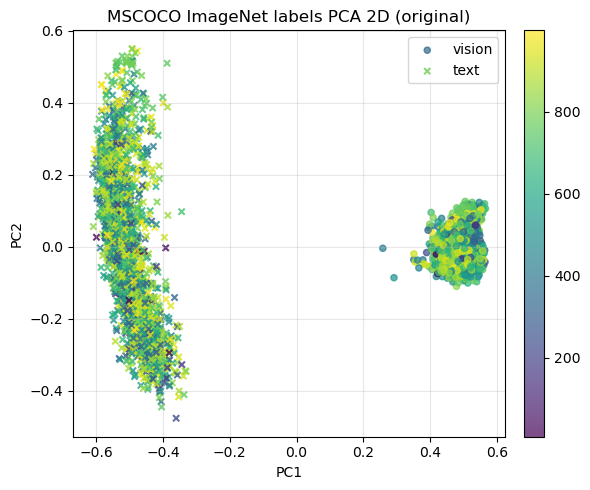

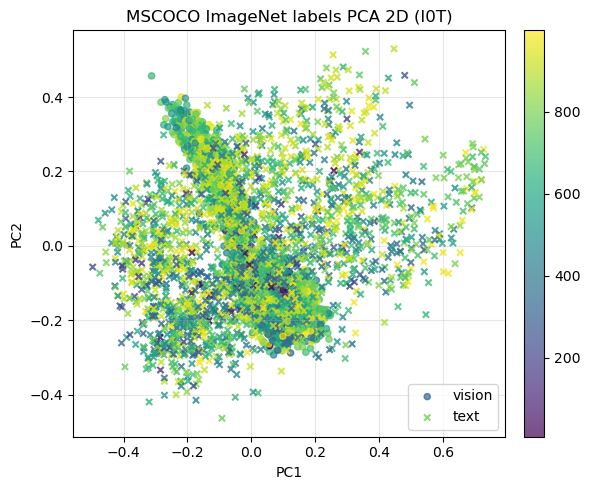

{'method': 'I0T',
 'dataset': 'mscoco_imagenet',
 'retrieval_orig': {1: 0.5101752877235413,
  5: 0.7420914769172668,
  10: 0.8212774395942688},
 'retrieval_i0t': {1: 0.48095908761024475,
  5: 0.7189199924468994,
  10: 0.8013298511505127},
 'gaps_orig': {'L2M': 0.9947764873504639,
  'L2I': 1.3029747009277344,
  'cosineTP': 0.15067575871944427,
  'RMG': 0.859423359334855},
 'gaps_i0t': {'L2M': 0.03385556489229202,
  'L2I': 1.1210999488830566,
  'cosineTP': 0.36828333139419556,
  'RMG': 0.7165990321683922},
 'mean_rmg_over_batches': {'orig': 0.859423359334855,
  'i0t': 0.7165990321683922},
 'statistics': {'mean_x': tensor([[ 0.0115, -0.0169, -0.0053,  ...,  0.0100,  0.0036,  0.0132]]),
  'mean_y': tensor([[ 0.0074,  0.0050,  0.0039,  ..., -0.0021,  0.0039, -0.0312]]),
  'n_fit': 10000,
  'embedding_dim': 1024,
  'mean_x_norm': 0.5981970429420471,
  'mean_y_norm': 0.7269570827484131},
 'clustering_orig': {'ARI': 0.12404974975620399,
  'NMI': np.float64(0.6580120802844309),
  'Homogeneity':

In [6]:
mscoco_cfg = copy.deepcopy(DEFAULT_CONFIGS["mscoco_imagenet"])
mscoco_cfg["seed"] = seed
mscoco_train_dir = EMBEDDING_PATHS["mscoco_train"]
mscoco_val_dir = EMBEDDING_PATHS["mscoco_val"]

mscoco_exp = build_mscoco_i0t_experiment(
    seed=mscoco_cfg["seed"],
    batch_size=mscoco_cfg["batch_size"],
    num_workers=mscoco_cfg["num_workers"],
    min_train_samples_per_class=mscoco_cfg["min_train_samples_per_class"],
    train_dir=mscoco_train_dir,
    val_dir=mscoco_val_dir,
)

print({
    "embedding_model": EMBEDDING_MODEL_NAME,
    "train_dir": mscoco_train_dir,
    "val_dir": mscoco_val_dir,
    "train_size": mscoco_exp["train_size"],
    "test_size": mscoco_exp["test_size"],
    "n_clusters": mscoco_exp["n_clusters"],
})

mscoco_statistics = fit_i0t_statistics_from_loader(
    mscoco_exp["train_loader"],
    n_fit=mscoco_cfg["n_fit"],
    device=device,
)

results_i0t_mscoco_imagenet = evaluate_i0t_mscoco_imagenet(
    mscoco_exp["test_loader"],
    mscoco_statistics,
    device=device,
    max_cluster_samples=mscoco_cfg["max_cluster_samples"],
    max_eval_batches=mscoco_cfg["max_eval_batches"],
    plot_pca=mscoco_cfg["plot_pca"],
    seed=seed,
)

results_i0t_mscoco_imagenet


## MSRVTT v2

[MSRVTTv2] 7010 unique videos from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_train | vision_emb=(7010, 512) | text_emb=(7010, 512) | num_classes=20
[MSRVTTv2] 1000 unique videos from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_test | vision_emb=(1000, 512) | text_emb=(1000, 512) | num_classes=20
{'train_size': 7010, 'test_size': 1000, 'n_clusters': 20}


RMG over batches: 100%|██████████| 4/4 [00:00<00:00, 395.34it/s]


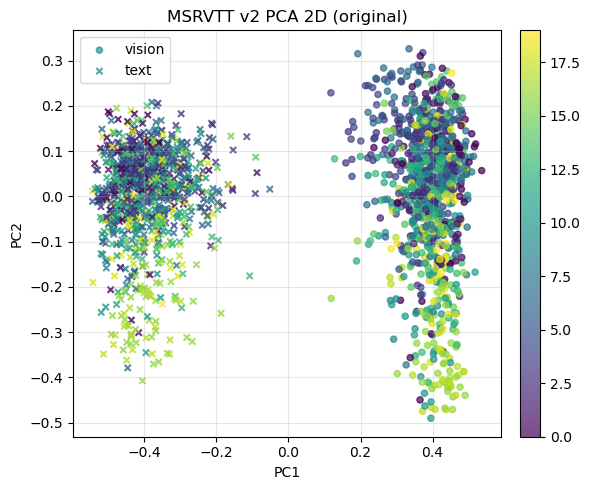

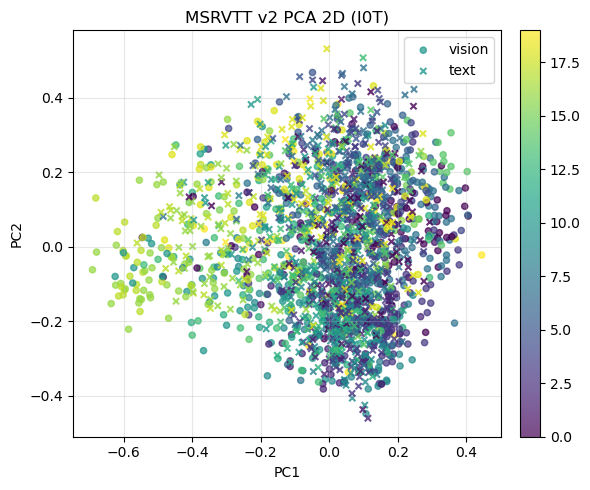

{'method': 'I0T',
 'dataset': 'msrvtt_v2',
 'retrieval_orig': {1: 0.32600000500679016,
  5: 0.5789999961853027,
  10: 0.6859999895095825},
 'retrieval_i0t': {1: 0.34599998593330383,
  5: 0.5759999752044678,
  10: 0.7009999752044678},
 'gaps_orig': {'L2M': 0.7806441187858582,
  'L2I': 1.1991441249847412,
  'cosineTP': 0.2800264060497284,
  'RMG': 0.8380064872521648},
 'gaps_i0t': {'L2M': 0.07942452281713486,
  'L2I': 1.2191202640533447,
  'cosineTP': 0.25315117835998535,
  'RMG': 0.7497735133151975},
 'mean_rmg_over_batches': {'orig': 0.8380064872521648,
  'i0t': 0.7497735133151975},
 'statistics': {'mean_x': tensor([[-1.5084e-02, -7.7525e-03, -6.6306e-03, -7.6190e-03, -1.7589e-02,
           -1.2404e-02, -1.0659e-02, -2.2356e-03, -7.1603e-03, -7.1023e-03,
           -5.1532e-04, -1.8667e-03,  1.0645e-02,  8.4115e-03, -9.6162e-03,
            2.6390e-03, -5.5873e-02, -1.0426e-02, -1.5400e-02,  3.7802e-03,
            7.0478e-03,  2.3584e-02,  1.4294e-02, -3.1586e-03, -1.0658e-02,
      

In [ ]:
msrvtt_cfg = copy.deepcopy(DEFAULT_CONFIGS["msrvtt_v2"])
msrvtt_cfg["seed"] = seed
msrvtt_train_dir = EMBEDDING_PATHS["msrvtt_train"]
msrvtt_test_dir = EMBEDDING_PATHS["msrvtt_test"]

msrvtt_exp = build_msrvtt_v2_i0t_experiment(
    seed=msrvtt_cfg["seed"],
    batch_size=msrvtt_cfg["batch_size"],
    num_workers=msrvtt_cfg["num_workers"],
    train_dir=msrvtt_train_dir,
    test_dir=msrvtt_test_dir,
)

print({
    "embedding_model": EMBEDDING_MODEL_NAME,
    "train_dir": msrvtt_train_dir,
    "test_dir": msrvtt_test_dir,
    "train_size": msrvtt_exp["train_size"],
    "test_size": msrvtt_exp["test_size"],
    "n_clusters": msrvtt_exp["n_clusters"],
})

msrvtt_statistics = fit_i0t_statistics_from_loader(
    msrvtt_exp["train_loader"],
    n_fit=msrvtt_cfg["n_fit"],
    device=device,
)

results_i0t_msrvtt_v2 = evaluate_i0t_msrvtt_v2(
    msrvtt_exp["test_loader"],
    msrvtt_statistics,
    device=device,
    max_cluster_samples=msrvtt_cfg["max_cluster_samples"],
    max_eval_batches=msrvtt_cfg["max_eval_batches"],
    plot_pca=msrvtt_cfg["plot_pca"],
    seed=seed,
)

results_i0t_msrvtt_v2


## Export results

In [7]:
# Optional override: set EXPORT_MODEL_NAME before this cell only if you want a different JSON key
# from the embedding model used above. In the common case, export uses EMBEDDING_MODEL_NAME.

results_to_save = {}
if "results_i0t_flickr30k" in globals():
    results_to_save["flickr30k"] = results_i0t_flickr30k
if "results_i0t_mscoco_imagenet" in globals():
    results_to_save["mscoco_imagenet"] = results_i0t_mscoco_imagenet
if "results_i0t_msrvtt_v2" in globals():
    results_to_save["msrvtt_v2"] = results_i0t_msrvtt_v2

export_model_name = globals().get("EXPORT_MODEL_NAME", EMBEDDING_MODEL_NAME)
export_path = export_i0t_results(
    results_to_save,
    "/mnt/media/emanuele/few_dimensions/comparison/results/i0t_evaluation_results.json",
    model_name=export_model_name,
    path_hints=list(EMBEDDING_PATHS.values()),
)

print(f"Saved compact I0T metrics to {export_path} under model={export_model_name} with updated datasets={list(results_to_save.keys())}")


Saved compact I0T metrics to /mnt/media/emanuele/few_dimensions/comparison/results/i0t_evaluation_results.json under model=ViT-L-16-SigLIP2-256___webli with updated datasets=['flickr30k', 'mscoco_imagenet']
